# Twitter sentiment word cloud
This notebook reads the hashed tweet dataset, stores it in a DataFrame, and creates separate word clouds for the `happy` and `sad` labels.

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

In [3]:
file_path = 'hasheddata-16k.txt'
df = pd.read_csv(
    file_path,
    sep='\s+',
    engine='python',
    header=None,
    names=['tweet_id', 'sentiment', 'tweet_text'],
    usecols=[0, 1, 2],
    na_values=[''],
    dtype={'tweet_id': 'string', 'sentiment': 'string', 'tweet_text': 'string'}
)

df = df.dropna().reset_index(drop=True)
df['sentiment'] = df['sentiment'].str.lower().str.strip()
df['tweet_text'] = df['tweet_text'].fillna('')
df.head()

<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/68/xj3vsfq10ln8p2rvh38hn_f40000gn/T/ipykernel_10385/668813967.py:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  sep='\s+',


,tweet_id,sentiment,tweet_text
0,595808317575954432,happy,gotta
1,595907875916111872,sad,emm
2,595807963413127169,happy,just
3,595907824720453632,sad,i
4,595807841916694529,happy,ahhhhhh


In [8]:
df.sentiment.value_counts()

sentiment
happy    7999
sad      7999
Name: count, dtype: Int64

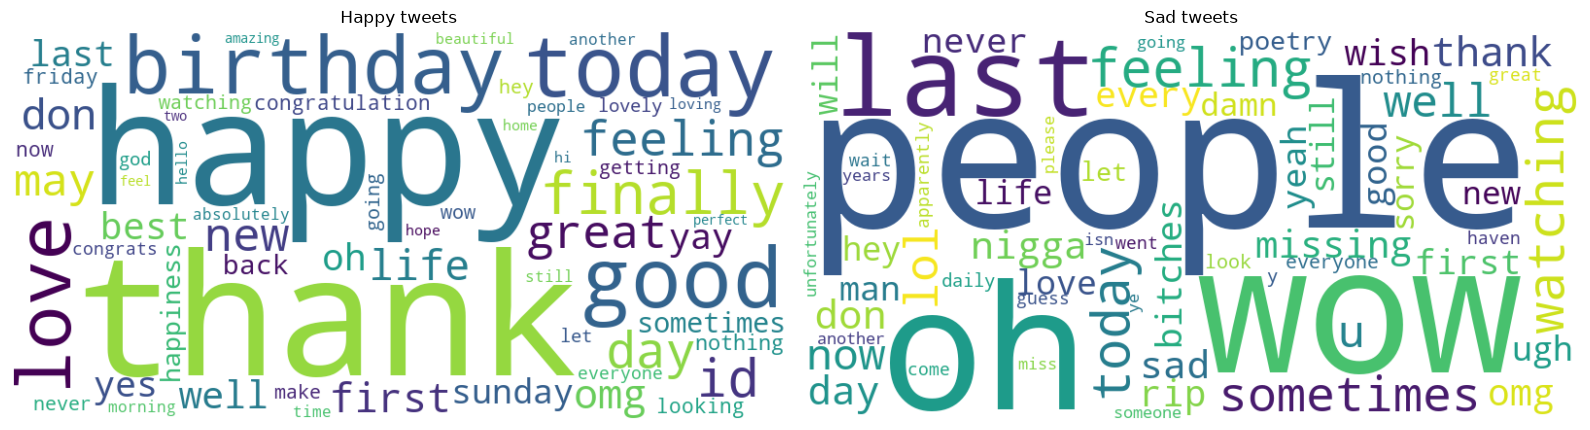

In [4]:
happy_text = ' '.join(df[df['sentiment'] == 'happy']['tweet_text'].astype(str))
sad_text = ' '.join(df[df['sentiment'] == 'sad']['tweet_text'].astype(str))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'https?\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

happy_clean = clean_text(happy_text)
sad_clean = clean_text(sad_text)

stopwords = set(STOPWORDS) | {'im', 'ive', 'gonna', 'gotta', 'dont', 'cant', 'wont', 's', 'm', 'll', 'just', 'really', 'like', 'one', 'get', 'got'}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, label, text in [
    (axes[0], 'Happy', happy_clean),
    (axes[1], 'Sad', sad_clean),
]:
    wc = WordCloud(
        background_color='white',
        colormap='viridis',
        max_words=60,
        stopwords=stopwords,
        width=800,
        height=400
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{label} tweets')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

X = df['tweet_text']
y = (df['sentiment'] == 'happy').astype(int)

vectorizer = TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1, 2), min_df=2)
X_tfidf = vectorizer.fit_transform(X)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=2000, class_weight='balanced')

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
results = cross_validate(model, X_tfidf, y, cv=cv, scoring=scoring)

for metric in scoring:
    mean_score = results[f'test_{metric}'].mean()
    print(f'{metric}: {mean_score:.4f}')


accuracy: 0.6088
precision: 0.7665
recall: 0.3129
f1: 0.4444
roc_auc: 0.6388


Confusion matrix:
[[1417  183]
 [1029  571]]


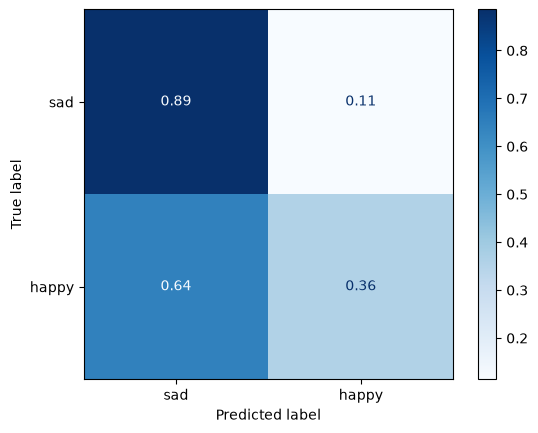

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X = df['tweet_text']
y = (df['sentiment'] == 'happy').astype(int)

vectorizer = TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1, 2), min_df=2)
X_tfidf = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=2000, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:')
print(cm)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['sad', 'happy'],
    cmap='Blues',
    normalize='true'
)
plt.show()


/Users/msayyadiharikan/Desktop/python/reddit/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11151.61it/s]


BERT embeddings + Logistic Regression (5-fold CV):
accuracy: 0.6354
precision: 0.6657
recall: 0.5441
f1: 0.5987
roc_auc: 0.6928

Classification report:
              precision    recall  f1-score   support

         sad       0.62      0.73      0.67      1600
       happy       0.68      0.56      0.61      1600

    accuracy                           0.64      3200
   macro avg       0.65      0.64      0.64      3200
weighted avg       0.65      0.64      0.64      3200


Confusion matrix:
[[1171  429]
 [ 709  891]]


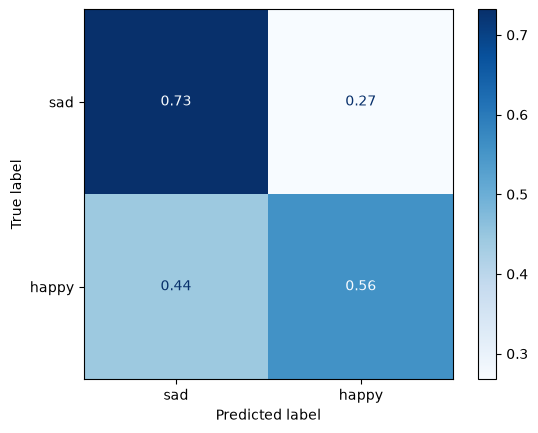

In [4]:
# BERT embeddings + Logistic Regression
# This section uses a lightweight transformer model to generate sentence embeddings,
# then trains a standard logistic regression classifier on top of those embeddings.

from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report

# Prepare labels
X_text = df['tweet_text'].astype(str).tolist()
y = (df['sentiment'] == 'happy').astype(int)

# Load a lightweight multilingual sentence embedding model
# This is a BERT-based encoder that produces a dense vector for each tweet.
model_bert = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Encode all tweets to embeddings
X_emb = model_bert.encode(X_text, show_progress_bar=False)

# Cross-validated logistic regression on BERT embeddings
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = LogisticRegression(max_iter=2000, class_weight='balanced')
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = cross_validate(clf, X_emb, y, cv=cv, scoring=scoring)

print('BERT embeddings + Logistic Regression (5-fold CV):')
for metric in scoring:
    print(f'{metric}: {results[f"test_{metric}"].mean():.4f}')

# Optional: train/test split and report
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X_emb, y, test_size=0.2, random_state=42, stratify=y
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['sad', 'happy']))

print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['sad', 'happy'],
    cmap='Blues',
    normalize='true'
)
plt.show()


XGBoost classification report:
              precision    recall  f1-score   support

         sad       0.63      0.74      0.68      1600
       happy       0.69      0.56      0.62      1600

    accuracy                           0.66      3200
   macro avg       0.66      0.66      0.65      3200
weighted avg       0.66      0.66      0.65      3200


XGBoost confusion matrix:
[[1192  408]
 [ 696  904]]


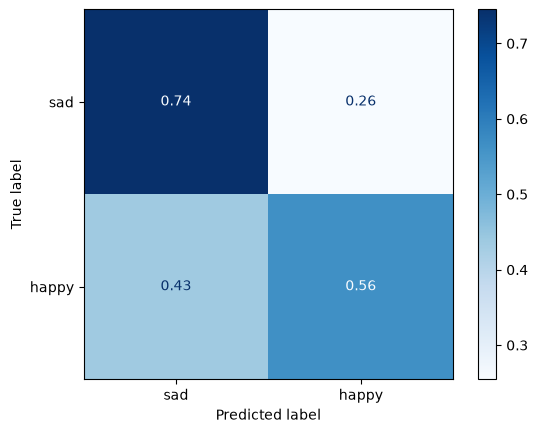


Misclassified tweets:
          tweet_id actual_label predicted_label    text
594847635766284289        happy             sad      it
594635564772626432        happy             sad     was
595527352781705217        happy             sad   girls
595258918617616384        happy             sad    when
594627649760206848        happy             sad      he
594717271118970880        happy             sad       i
594420215997300736        happy             sad    when
594137299278934016          sad           happy  magnet
595327190809452544        happy             sad     now
595627620429131776        happy             sad  taylor
594735991530729472        happy             sad   wahhh
593877175784333313          sad           happy       a
595622396402466816        happy             sad     twt
595780565275680768          sad           happy    love
595522235416367104        happy             sad      tt
594317506237468673        happy             sad because
594720565153280000       

In [5]:
# XGBoost on BERT embeddings
# Keep tweet IDs and original text so we can inspect bad predictions later.
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

X = X_emb
ids = df['tweet_id'].astype(str).to_numpy()
texts = df['tweet_text'].astype(str).to_numpy()

X_train, X_test, y_train, y_test, ids_train, ids_test, texts_train, texts_test = train_test_split(
    X, y, ids, texts, test_size=0.2, random_state=42, stratify=y
)

xgb = XGBClassifier(
    objective='binary:logistic',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=1,
    verbosity=0
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print('XGBoost classification report:')
print(classification_report(y_test, y_pred, target_names=['sad', 'happy']))

print('\nXGBoost confusion matrix:')
print(confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['sad', 'happy'],
    cmap='Blues',
    normalize='true'
)
plt.show()

# Error analysis: look at the tweets that were misclassified.
results_df = pd.DataFrame({
    'tweet_id': ids_test,
    'text': texts_test,
    'actual': y_test,
    'predicted': y_pred,
    'correct': y_pred == y_test,
})

misclassified = results_df[results_df['correct'] == False].copy()
misclassified['actual_label'] = misclassified['actual'].map({0: 'sad', 1: 'happy'})
misclassified['predicted_label'] = misclassified['predicted'].map({0: 'sad', 1: 'happy'})

print('\nMisclassified tweets:')
print(misclassified[['tweet_id', 'actual_label', 'predicted_label', 'text']].head(20).to_string(index=False))


In [9]:
# Show a few misclassified tweets with simple explanations
if 'results_df' not in globals():
    if all(name in globals() for name in ['y_test', 'y_pred', 'ids_test', 'texts_test']):
        results_df = pd.DataFrame({
            'tweet_id': ids_test.astype(str),
            'text': texts_test.astype(str),
            'actual': y_test.astype(int),
            'predicted': y_pred.astype(int),
            'correct': y_pred == y_test,
        })
    else:
        raise ValueError('Run the XGBoost cell first so that y_test, y_pred, ids_test, and texts_test exist.')

if 'actual_label' not in results_df.columns:
    results_df['actual_label'] = results_df['actual'].map({0: 'sad', 1: 'happy'})
if 'predicted_label' not in results_df.columns:
    results_df['predicted_label'] = results_df['predicted'].map({0: 'sad', 1: 'happy'})

misclassified = results_df[results_df['correct'] == False].head(10).reset_index(drop=True)

for i, row in misclassified.iterrows():
    actual = row['actual_label']
    predicted = row['predicted_label']
    text = row['text']
    print(f'Example {i + 1}:')
    print(f'  tweet_id: {row["tweet_id"]}')
    print(f'  actual: {actual}, predicted: {predicted}')
    print(f'  text: {text}')
    if actual == 'happy' and predicted == 'sad':
        print('  explanation: likely confused by short, neutral, or ambiguous text that lacks strongly positive cues.')
    elif actual == 'sad' and predicted == 'happy':
        print('  explanation: likely confused by mixed sentiment language or a word that sounds positive in context.')
    else:
        print('  explanation: borderline example with weak sentiment signal.')
    print('-' * 80)


Example 1:
  tweet_id: 594847635766284289
  actual: happy, predicted: sad
  text: it
  explanation: likely confused by short, neutral, or ambiguous text that lacks strongly positive cues.
--------------------------------------------------------------------------------
Example 2:
  tweet_id: 594635564772626432
  actual: happy, predicted: sad
  text: was
  explanation: likely confused by short, neutral, or ambiguous text that lacks strongly positive cues.
--------------------------------------------------------------------------------
Example 3:
  tweet_id: 595527352781705217
  actual: happy, predicted: sad
  text: girls
  explanation: likely confused by short, neutral, or ambiguous text that lacks strongly positive cues.
--------------------------------------------------------------------------------
Example 4:
  tweet_id: 595258918617616384
  actual: happy, predicted: sad
  text: when
  explanation: likely confused by short, neutral, or ambiguous text that lacks strongly positive cues.